In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve.solvers import NewtonMinimization
from netgen.webgui import Draw as DrawGeo

**Geometry and Mesh**

In [78]:
# Parameters and constants
r_ball = 0.1
h_fall = 0.01
initial_y_velocity = 0.0
g = 9.81

v_max_th = np.sqrt(2*g*(h_fall))

maxh = r_ball / 5
mesh_order = 3

# Symmetry flag
use_symmetry = False

# Geometry parameters
rect_len_x = 3 * r_ball
rect_len_y = r_ball / 4
h0_ball = rect_len_y + r_ball + h_fall

# Define wall geometry
wall = MoveTo(-rect_len_x/2, 0).Rectangle(rect_len_x, rect_len_y).Face()
wall.edges.Max(Y).maxh = r_ball/20
wall.edges.Max(Y).name = "contact_wall"
wall.edges.Min(Y).name = "fix_y"
wall.edges.Max(X).name = "fix_x"
wall.edges.Min(X).name = "fix_x"
wall.name = "wall"

# Define ball geometry
ball = Circle((0, h0_ball), r_ball).Face()
ball.edges.Max(Y).maxh = r_ball/20
ball.edges.name = "contact_ball"
ball.name = "ball"

if use_symmetry:
    # Cut at y=0 for symmetry
    sym_cut = MoveTo(-rect_len_x/2,0).Rectangle(rect_len_x/2, rect_len_y + h0_ball + r_ball).Face()
    sym_cut.edges.Max(X).name = "sym"

    wall = wall - sym_cut
    ball = ball - sym_cut

geo = Compound([ball, wall])
geo = OCCGeometry(geo, dim = 2)

mesh = Mesh(geo.GenerateMesh(maxh=maxh, quad_dominated=False))
mesh.Curve(mesh_order)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

**Material Parameters**

In [4]:
# Rigid steel material for wall
E_wall, nu_wall = 210e9, 0.2
rho_wall = 7850
thickness = 1
mu_wall  = E_wall / 2 / (1+nu_wall)
lam_wall = E_wall * nu_wall / ((1+nu_wall)*(1-2*nu_wall))

In [72]:
# Linear Elasticity
def eps(u):
    return Sym(Grad(u))

def linear_elastic_strain_energy_density(eps, lam, mu):
    return 0.5*lam*Trace(eps)**2 + mu*InnerProduct(eps, eps)

def stress_hooke(eps, lam, mu):
    sigma = 2 * mu * eps + lam * Trace(eps) * Id(mesh.dim)
    return sigma

# Neo-Hookean
def C(u):
    F = Id(mesh.dim) + Grad(u)
    return F.trans * F

def neo_hookean (C, lam, mu):
    return 0.5*mu*(Trace(C-Id(mesh.dim)) + 2*mu/lam*Det(C)**(-lam/2/mu)-1)

def stress_neo_hookean(C, lam, mu):
    return 0.5 * mu * (Id(mesh.dim) - Det(C) ** (-lam / 2 / mu) * Inv(C))    

# Energy densities
def gravitational_energy_density(u, rho):
    # y_current = y + u_y
    return rho * g * (y + u[1])

def kinetic_energy_density(v_mid, rho):
    return 0.5 * rho * InnerProduct(v_mid, v_mid)

In [ ]:
def run_test_case(config):
    # Material parameters
    E = config['E']
    nu = config['nu']
    rho = config['rho']
    material_law = config['material_law']
    gap_type = config['gap_type']
    kn = config['kn']

    mu  = E / 2 / (1+nu)
    lam = E * nu / ((1+nu)*(1-2*nu))
    
    # Select material law
    strain_energy_density = None
    deformation_gradient  = None

    if material_law == "linear_elastic":
        strain_energy_density = linear_elastic_strain_energy_density
        deformation_gradient  = eps
        stress_func = stress_hooke

    elif material_law == "neo_hookean":
        strain_energy_density = neo_hookean
        deformation_gradient  = C
        stress_func = stress_neo_hookean
    
    # Time stepping parameters
    tau  = 5e-4
    t    = 0
    tend = 0.2
    
    # Finite Element Space and Grid Functions
    fes = VectorH1(mesh, order=mesh_order, dirichletx="fix_x|sym", dirichlety="fix_y")
    fes_stress = MatrixValued(H1(mesh, order=mesh_order, definedon=mesh.Materials("ball")))
    u, v = fes.TnT()

    u_old = GridFunction(fes)
    u_new = GridFunction(fes)

    v_old = GridFunction(fes)
    v_new = GridFunction(fes)

    a_new = GridFunction(fes)
    a_old = GridFunction(fes)
    
    stress = GridFunction(fes_stress)

    u_history = GridFunction(fes, multidim=0)
    v_history = GridFunction(fes, multidim=0)
    a_history = GridFunction(fes, multidim=0)
    
    stress_history = GridFunction(fes_stress, multidim=0)
    
    #Setup initial velocity and acceleration
    u_new.Set( (0, initial_y_velocity) )
    v_new.Set( (0,0) )
    
    #-------------------------------------------------------
    # Bilinear form
    bfmstar = BilinearForm(fes)
    
    # Add strain energy term wall (always linear elastic)
    bfmstar += Variation( linear_elastic_strain_energy_density(eps(u), lam_wall, mu_wall).Compile(False) * dx("wall") )
    
    # Add strain energy term ball
    bfmstar += Variation( strain_energy_density(deformation_gradient(u), lam, mu).Compile(False) * dx("ball") )

    # Define gravitational force
    force = CF((0,-g*rho*thickness))

    # Add gravitational force term
    bfmstar += Variation( -force * 0.5*(u + u_old) * dx("ball") )

    # Add inertial term (Newmark method)
    bfmstar += Variation( rho/2 * 2/tau**2 * (u - u_old - tau*v_new -tau**2/4*a_old)**2 * dx("ball") )
    
    #-------------------------------------------------------
    # Contact Definition
    master = mesh.Boundaries("contact_wall")
    slave = mesh.Boundaries("contact_ball")
    contact = ContactBoundary(master, slave)

    X_M = CoefficientFunction((x,y))
    X_S = X_M.Other()
    n_S = -specialcf.normal(2).Other()
    
    if gap_type == "absolute":
        cur_pos_master = X_M + u
        cur_pos_slave = X_S + u.Other()
        cf = (cur_pos_master - cur_pos_slave) * n_S
    
    elif gap_type == "incremental":
        increment_master = X_M + u - u_old
        increment_slave = X_S + u.Other() - u_old.Other()
        cf = (increment_master - increment_slave) * n_S
    
    penalty_energy = kn * cf * cf
    contact.AddEnergy(IfPos(cf, penalty_energy, 0), deformed = True)
    
    #-------------------------------------------------------
    # Analytical total energy
    area_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
    E_tot_analytical = rho * g * area_ball * (h0_ball)

    # History Lists
    time_hist   = []
    E_kin_hist  = []
    E_grav_hist = []
    E_ela_hist  = []
    E_con_hist  = []
    E_tot_hist  = []
    vy_cm_hist  = []
    
    # Visualization
    #scene_u = Draw (u_new, mesh, "disp", deformation=u_new)   
    scene_sig = Draw (Norm(stress), mesh, "stress", deformation=u_new, colormap="jet")
    
    #-------------------------------------------------------
    # Simulation loop
    i = 0
    with TaskManager():
        while t < tend:
            t += tau
            
            # Time step update
            u_old.vec.data = u_new.vec
            v_old.vec.data = v_new.vec
            a_old.vec.data = a_new.vec

            # Update contact and solve for new displacement
            contact.Update(u_old, bfmstar, 5, 0.01)
            NewtonMinimization (a=bfmstar, u=u_new, printing=False, inverse="sparsecholesky")
            
            # Update acceleration and velocity (Newmark)
            a_new.vec.data  = u_new.vec - u_old.vec - tau*v_new.vec - (tau**2/4)*a_old.vec
            a_new.vec.data *= 4/tau**2
            v_new.vec.data += 0.5*tau*a_old.vec
            v_new.vec.data += 0.5*tau*a_new.vec
            
            # Update stress
            stress.Interpolate(stress_func(deformation_gradient(u_new), lam, mu))
            # if material_law == "linear_elastic":
            #     stress.Interpolate(stress_hooke(eps(u_new), lam, mu))
            # elif material_law == "neo_hookean":
            #     stress.Interpolate(stress_neo_hookean(C(u_new), lam, mu))
                
            # Only norm of stress
            #stress.Set(Norm(stress))
            
            # Store history
            u_history.AddMultiDimComponent(u_new.vec)
            v_history.AddMultiDimComponent(v_new.vec)
            a_history.AddMultiDimComponent(a_new.vec)
            stress_history.AddMultiDimComponent(stress.vec)
            
            # Mid point velocity
            u_mid = 0.5 * (u_old + u_new)
            v_mid = 0.5 * (v_old + v_new)
            
            # Energies
            E_kin       = Integrate( kinetic_energy_density(v_mid, rho), mesh, definedon=mesh.Materials("ball"))
            E_grav      = Integrate( gravitational_energy_density(u_mid, rho), mesh, definedon=mesh.Materials("ball") )
            E_ela_ball  = Integrate( strain_energy_density(deformation_gradient(u_new), lam, mu), mesh, definedon=mesh.Materials("ball") )
            E_ela_wall  = Integrate( linear_elastic_strain_energy_density(eps(u_new), lam_wall, mu_wall), mesh, definedon=mesh.Materials("wall") )
            E_ela       = E_ela_ball + E_ela_wall
            
            E_tot  = E_kin + E_ela + E_grav
            E_con  = E_tot_analytical - E_tot
            
            #E_contact = Integrate(IfPos(cf, kn*cf*cf, 0), mesh, definedon=mesh.Boundaries("contact_ball"))
            #rel_error = abs(E_tot - E_tot_analytical) / abs(E_tot_analytical) * 100
            vy_avg = Integrate(v_new[1], mesh, definedon=mesh.Materials("ball")) / area_ball
            vy_cm_hist.append(vy_avg)
            
            time_hist.append(t)
            E_kin_hist.append(E_kin)
            E_ela_hist.append(E_ela)
            E_grav_hist.append(E_grav)
            E_tot_hist.append(E_tot)
            E_con_hist.append(E_con)    
            
            if i % 50 == 0:
                print(f"t: {t:.4f} / {tend:.4f}")
            i += 1

            #scene_u.Redraw()
            scene_sig.Redraw()
    
    return {
        "time": time_hist,
        "E_kin": E_kin_hist,
        "E_ela": E_ela_hist,
        "E_grav": E_grav_hist,
        "E_tot": E_tot_hist,
        "E_con": E_con_hist,
        "vy_cm": vy_cm_hist,
        "u_history": u_history,
        "sigma_history": stress_history
    }

In [74]:
settings = {"Multidim": {
                    "speed" : 30
                }}

def animate(u_hist, settings=settings):

    Draw(u_hist, mesh,
         interpolation_multidim=True,
         deformation = u_hist,
         animate = True,
         autoscale=False,
         min = 0, max = 1.2*h_fall,
         settings = settings
    )

### Test Cases: Linear Elasticity

In [75]:
config_1 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'incremental',
            'kn': 1e11}

res_config_1 = run_test_case(config_1)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [79]:
u_hist = res_config_1['u_history']
animate(u_hist)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

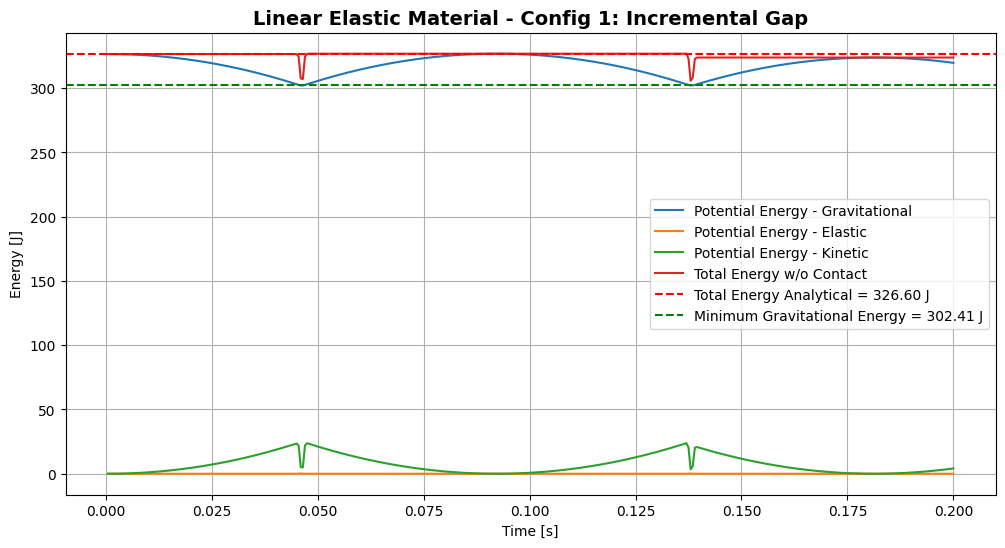

In [83]:
# Calculate Relative energy error for the different configurations
rho = config_1['rho']
A_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
E_tot_th = rho * g * A_ball * thickness * (h0_ball)
E_grav_min_th = rho * g * A_ball * thickness * (h0_ball - h_fall)

plt.figure(figsize=(12,6))
plt.title("Linear Elastic Material - Config 1: Incremental Gap", fontsize=14, fontweight='bold')
plt.plot(res_config_1['time'], res_config_1['E_grav'], label='Potential Energy - Gravitational')
plt.plot(res_config_1['time'], res_config_1['E_ela'], label='Potential Energy - Elastic')
plt.plot(res_config_1['time'], res_config_1['E_kin'], label='Potential Energy - Kinetic')
plt.plot(res_config_1['time'], res_config_1['E_tot'], label='Total Energy w/o Contact')
plt.axhline(E_tot_th, color='r', linestyle='--', label=f'Total Energy Analytical = {E_tot_th:.2f} J')
plt.axhline(E_grav_min_th, color='g', linestyle='--', label=f'Minimum Gravitational Energy = {E_grav_min_th:.2f} J')
plt.xlabel('Time [s]')
plt.ylabel('Energy [J]')
plt.legend()
plt.grid()
plt.savefig('images/linear_elastic_config1_energy.svg', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
config_2 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'incremental',
            'kn': 1e9}

res_config_2 = run_test_case(config_2)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [41]:
animate(res_config_2['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [13]:
config_3 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'absolute',
            'kn': 5e6}

res_config_3 = run_test_case(config_3)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [42]:
animate(res_config_3['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [14]:
config_4 = {'E': 210e9,
            'nu': 0.3,
            'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'absolute',
            'kn': 1e7}

res_config_4 = run_test_case(config_4)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [43]:
animate(res_config_4['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [15]:
configs_1 = [config_1, config_2, config_3, config_4]
results_1 = [res_config_1, res_config_2, res_config_3, res_config_4]

times_1   = [np.array(res["time"]) for res in results_1]
E_kins_1  = [np.array(res["E_kin"]) for res in results_1]
E_elas_1  = [np.array(res["E_ela"])for res in results_1]
E_gravs_1 = [np.array(res["E_grav"]) for res in results_1]
E_tots_1  = [np.array(res["E_tot"]) for res in results_1]
E_cons_1  = [np.array(res["E_con"]) for res in results_1]
vy_cms_1  = [np.array(res["vy_cm"]) for res in results_1]

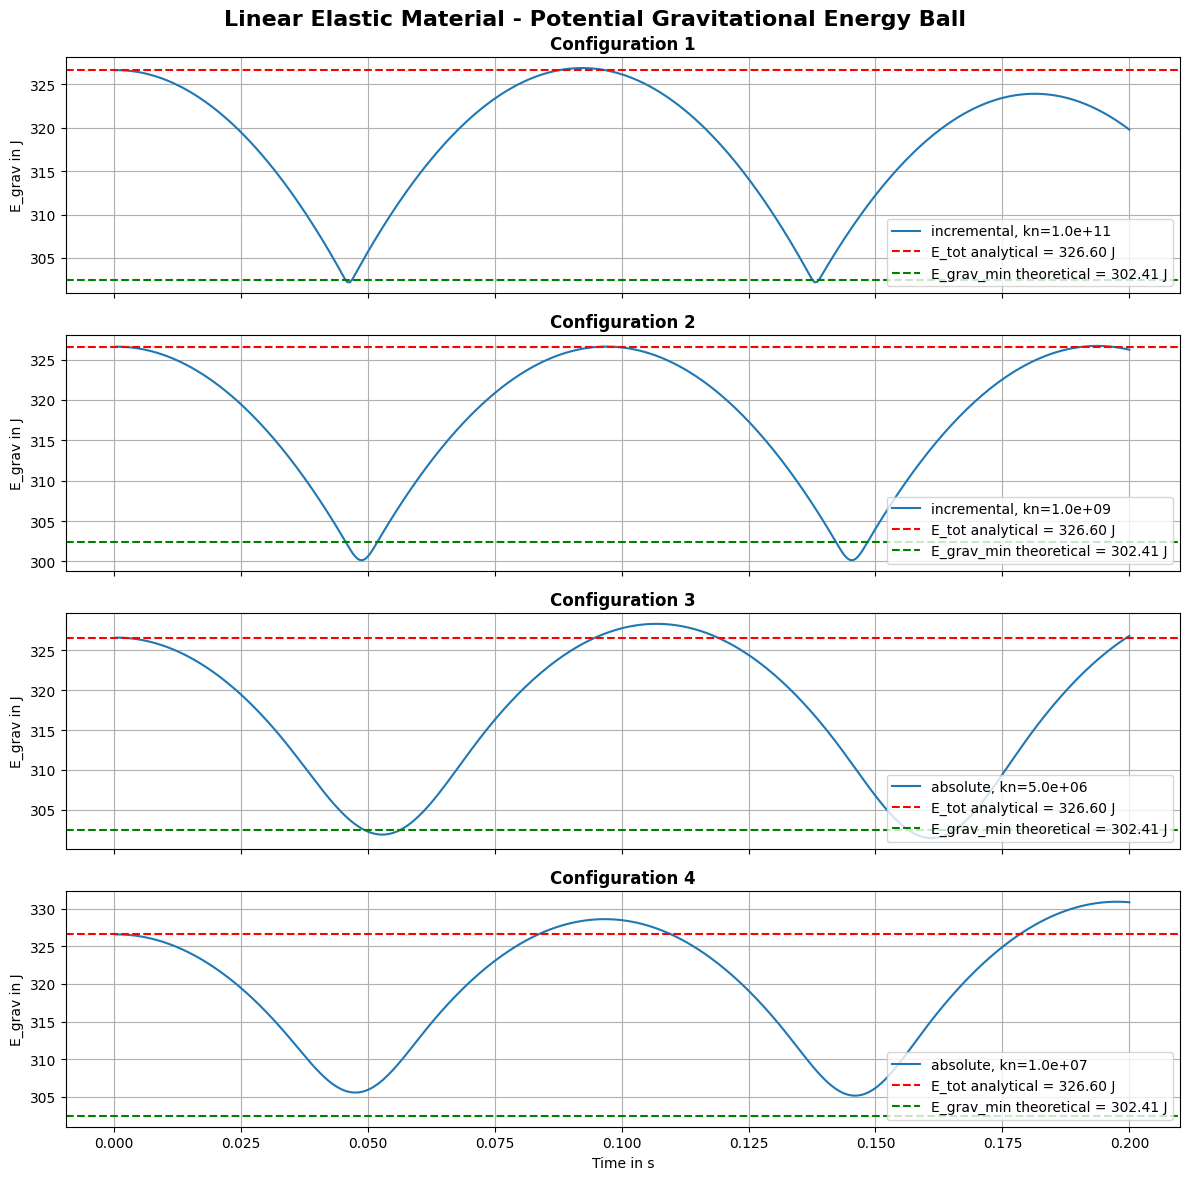

In [84]:
# Plot gravitational energies for all linear elastic cases
fig, axs = plt.subplots(len(E_gravs_1), 1, figsize=(12, 3*len(E_gravs_1)), sharex=True)
fig.suptitle('Linear Elastic Material - Potential Gravitational Energy Ball', fontsize=16, fontweight='bold')
for i, E_grav in enumerate(E_gravs_1):
    axs[i].plot(times_1[i], E_grav, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}')
    axs[i].axhline(E_tot_th, color='r', linestyle='--', label=f'E_tot analytical = {E_tot_th:.2f} J')
    axs[i].axhline(E_grav_min_th, color='g', linestyle='--', label=f'E_grav_min theoretical = {E_grav_min_th:.2f} J')
    axs[i].set_ylabel('E_grav in J')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].legend(loc='lower right')
    axs[i].grid()
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.savefig('images/linear_elastic_gravitationa_energy.svg', dpi=300, bbox_inches='tight')
plt.show()


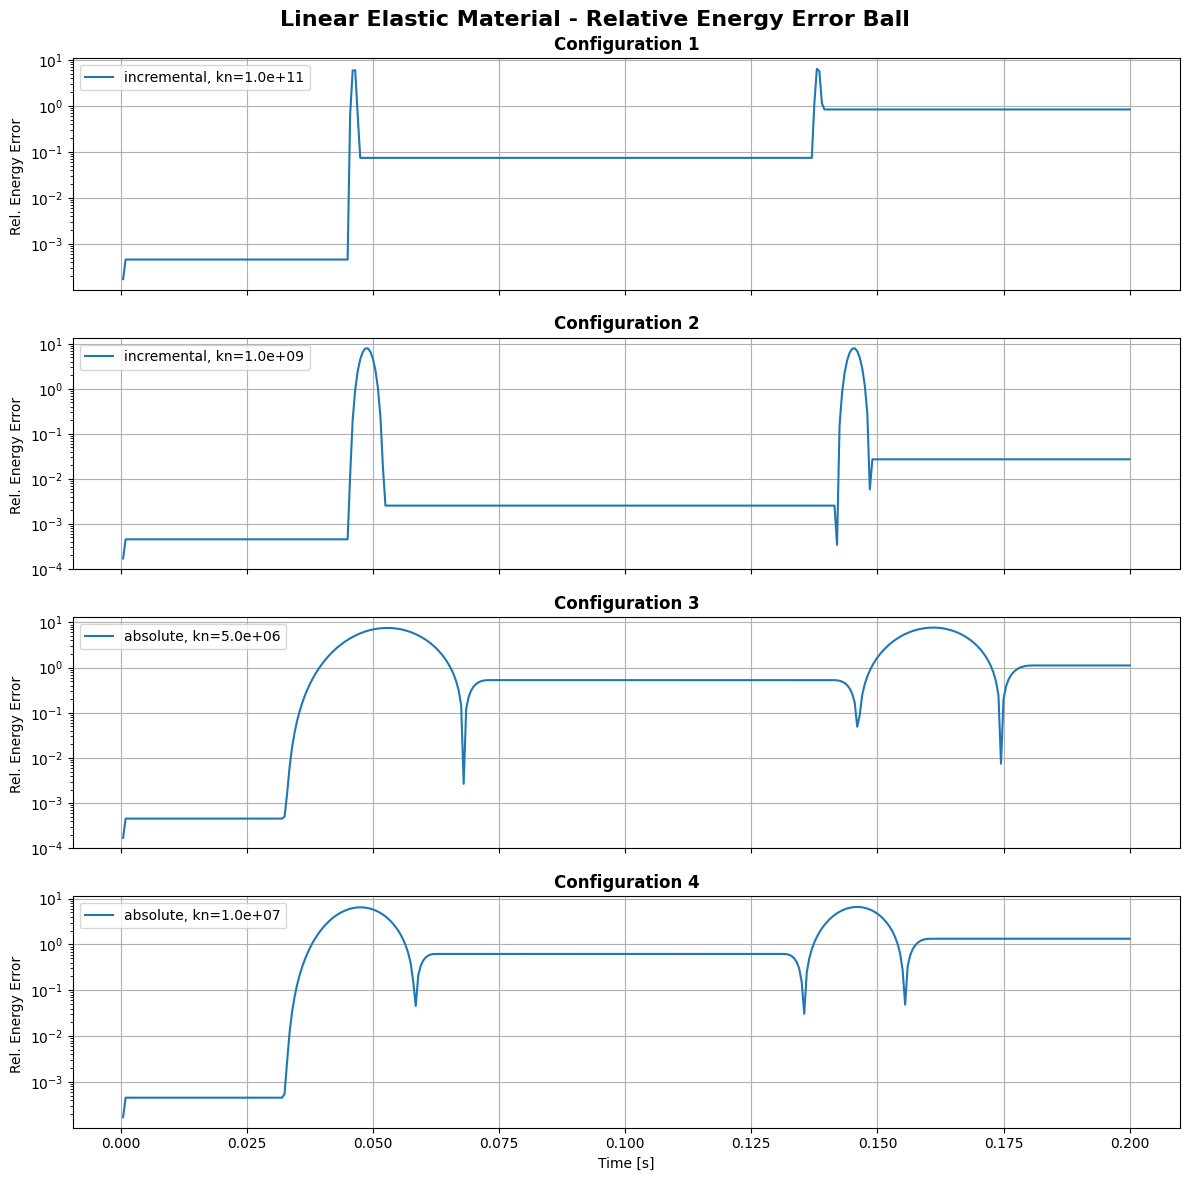

In [85]:
rel_errors_1 = [abs(E_tot - E_tot_th) / abs(E_tot_th) for E_tot in E_tots_1]

# Plotting
fig, axs = plt.subplots(len(rel_errors_1), 1, figsize=(12, 3*len(rel_errors_1)), sharex=True)
fig.suptitle('Linear Elastic Material - Relative Energy Error Ball', fontsize=16, fontweight='bold')
for i, rel_error in enumerate(rel_errors_1):
    axs[i].semilogy(times_1[i], np.array(rel_error)*100, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}')
    axs[i].set_ylabel('Rel. Energy Error ')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='upper left')
axs[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.savefig('images/linear_elastic_rel_error.svg', dpi=300, bbox_inches='tight')
plt.show()

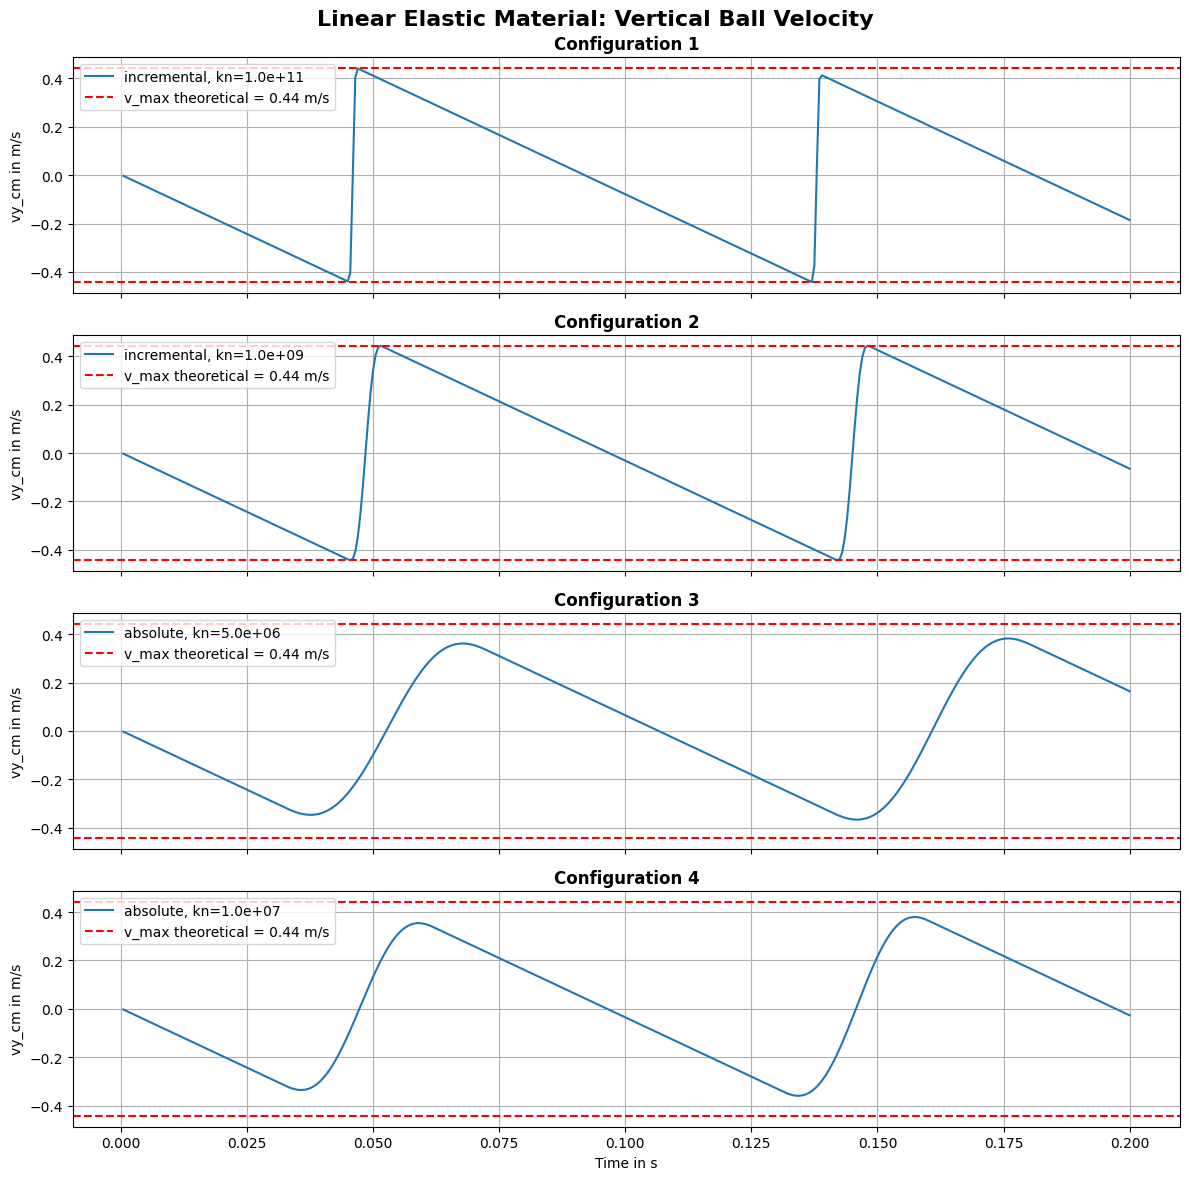

In [35]:
fig, axs = plt.subplots(len(vy_cms_1), 1, figsize=(12, 3*len(vy_cms_1)), sharex=True)
fig.suptitle('Linear Elastic Material: Vertical Ball Velocity', fontsize=16, fontweight='bold')
for i, vy_cm in enumerate(vy_cms_1):
    axs[i].plot(times_1[i], vy_cm, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}')
    axs[i].axhline(v_max_th, color='r', linestyle='--', label='v_max theoretical = {:.2f} m/s'.format(v_max_th))
    axs[i].axhline(-v_max_th, color='r', linestyle='--')
    axs[i].set_ylim(-1.1*v_max_th, 1.1*v_max_th)
    axs[i].set_ylabel('vy_cm in m/s')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='upper left')
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.savefig('images/linear_elastic_v_ball.png', dpi=300)
plt.show()

### Test Case 2: Hyperelasticity (Neo-Hookean)

In [ ]:
config_5 = {'E': 5e4,
            'nu': 0.45,
            'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'incremental',
            'kn': 1e7}

res_config_5 = run_test_case(config_5)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000


In [44]:
animate(res_config_5['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [20]:
vtk = VTKOutput(mesh, coefs=[res_config_5["u_history"]], names=["displacement"], filename="contact_neo_hookean")
vtk.Do()

'contact_neo_hookean'

In [22]:
config_6 = {'E': 5e4,
            'nu': 0.45,
            'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'incremental',
            'kn': 1e6}

res_config_6 = run_test_case(config_6)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

t: 0.0005 / 0.2000
t: 0.0255 / 0.2000
t: 0.0505 / 0.2000
t: 0.0755 / 0.2000
t: 0.1005 / 0.2000
t: 0.1255 / 0.2000
t: 0.1505 / 0.2000
t: 0.1755 / 0.2000


In [45]:
animate(res_config_6['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [77]:
# config_7 = {'E': 5e4,
#             'nu': 0.45,
#             'rho': 1000,
#             'material_law': 'neo_hookean',
#             'gap_type': 'absolute',
#             'kn': 1e5}

# res_config_7 = run_test_case(config_7)

In [24]:
configs_2 = [config_5, config_6]#, config_7]
results_2 = [res_config_5, res_config_6]#, res_config_7]

times_2   = [np.array(res["time"]) for res in results_2]
E_kins_2  = [np.array(res["E_kin"]) for res in results_2]
E_elas_2  = [np.array(res["E_ela"])for res in results_2]
E_gravs_2 = [np.array(res["E_grav"]) for res in results_2]
E_tots_2  = [np.array(res["E_tot"]) for res in results_2]
E_cons_2  = [np.array(res["E_con"]) for res in results_2]
vy_cms_2  = [np.array(res["vy_cm"]) for res in results_2]

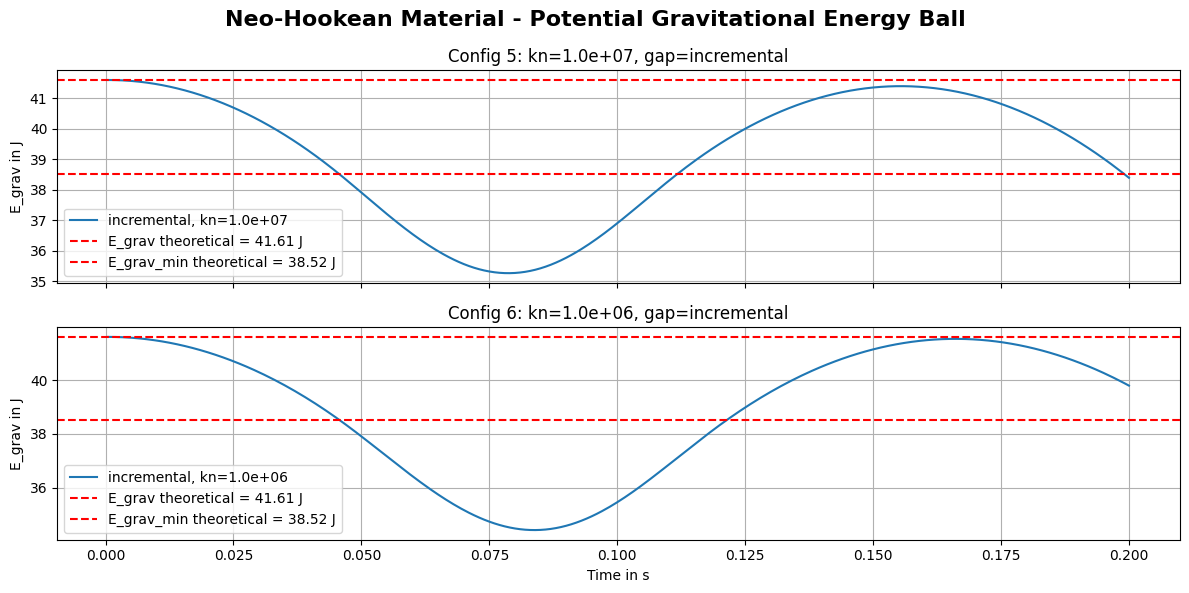

In [86]:
# Plot gravitational energies for neo-hookean cases
E_tot_th_2 = config_5['rho'] * g * Integrate(1, mesh, definedon=mesh.Materials("ball")) * (h0_ball)
E_grav_min_th_2 = config_5['rho'] * g * Integrate(1, mesh, definedon=mesh.Materials("ball")) * (h0_ball - h_fall)

fig, axs = plt.subplots(len(E_gravs_2), 1, figsize=(12, 3*len(E_gravs_2)), sharex=True)
fig.suptitle('Neo-Hookean Material - Potential Gravitational Energy Ball', fontsize=16, fontweight='bold')
for i, E_grav in enumerate(E_gravs_2):
    axs[i].plot(times_2[i], E_grav, label=f'{configs_2[i]["gap_type"]}, kn={configs_2[i]["kn"]:.1e}')
    axs[i].axhline(E_tot_th_2, color='r', linestyle='--', label=f'E_grav theoretical = {E_tot_th_2:.2f} J')
    axs[i].axhline(E_grav_min_th_2, color='r', linestyle='--', label=f'E_grav_min theoretical = {E_grav_min_th_2:.2f} J')
    axs[i].set_ylabel('E_grav in J')
    axs[i].set_title(f'Config {i+5}: kn={configs_2[i]["kn"]:.1e}, gap={configs_2[i]["gap_type"]}')
    axs[i].grid()
    axs[i].legend()
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.savefig('images/neo_hookean_gravitationa_energy.svg', dpi=300, bbox_inches='tight')
plt.show()

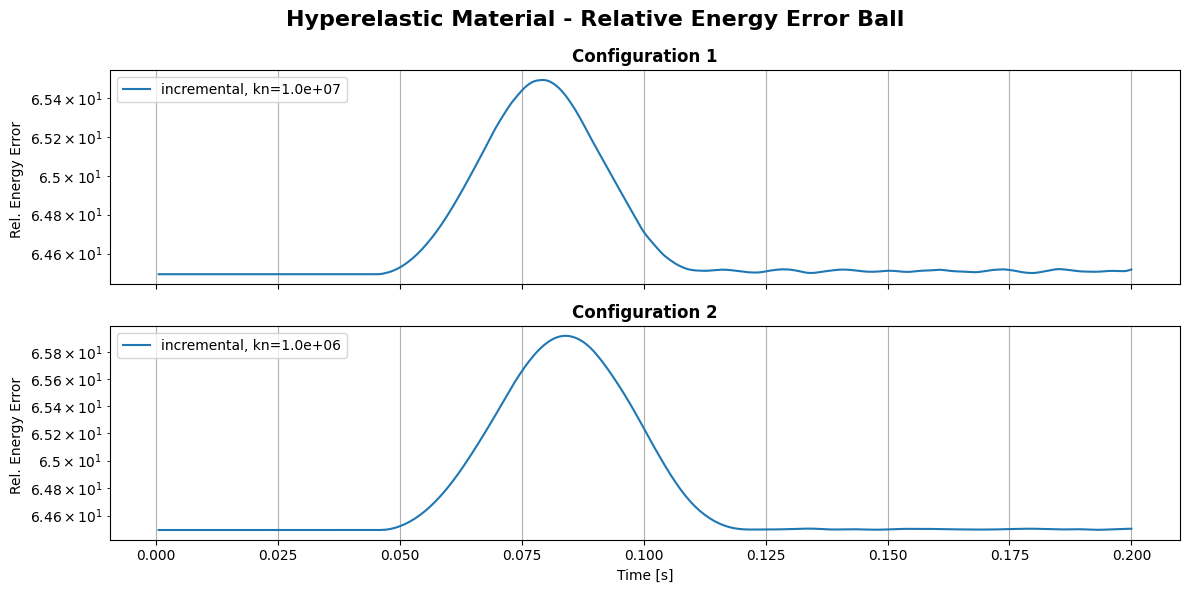

In [87]:
rel_errors_2 = [abs(E_tot - E_tot_th_2) / abs(E_tot_th) for E_tot in E_tots_2]

# Plotting
fig, axs = plt.subplots(len(rel_errors_2), 1, figsize=(12, 3*len(rel_errors_2)), sharex=True)
fig.suptitle('Hyperelastic Material - Relative Energy Error Ball', fontsize=16, fontweight='bold')
for i, rel_error in enumerate(rel_errors_2):
    axs[i].semilogy(times_2[i], np.array(rel_error)*100, label=f'{configs_2[i]["gap_type"]}, kn={configs_2[i]["kn"]:.1e}')
    axs[i].set_ylabel('Rel. Energy Error ')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='upper left')
axs[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.savefig('images/hyperelastic_rel_error.svg', dpi=300, bbox_inches='tight')
plt.show()

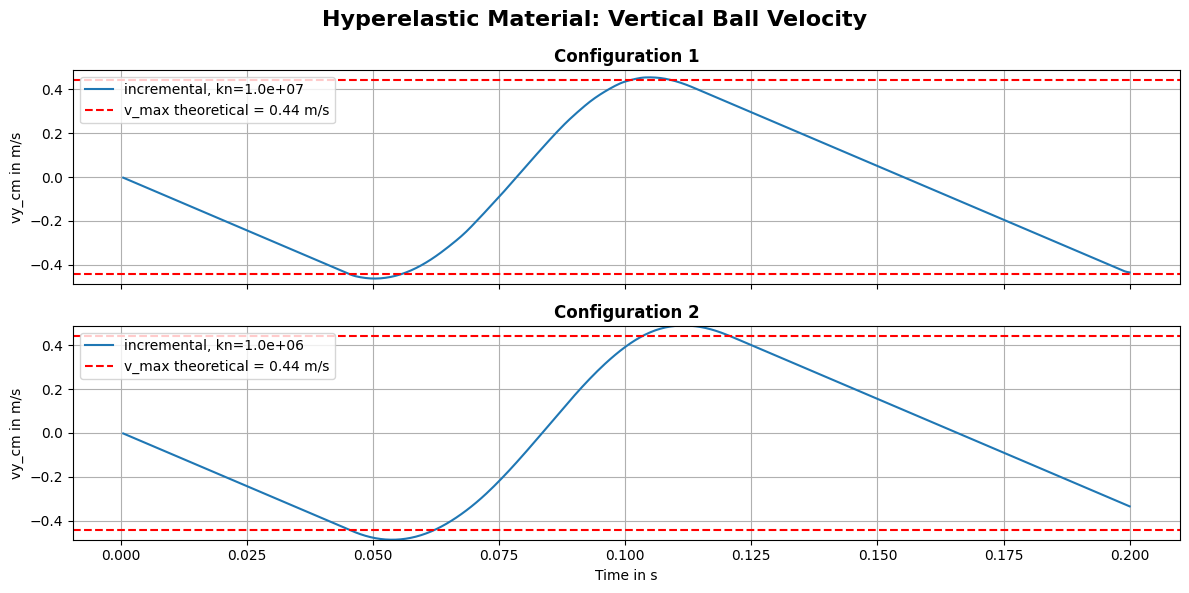

In [88]:
fig, axs = plt.subplots(len(vy_cms_2), 1, figsize=(12, 3*len(vy_cms_2)), sharex=True)
fig.suptitle('Hyperelastic Material: Vertical Ball Velocity', fontsize=16, fontweight='bold')
for i, vy_cm in enumerate(vy_cms_2):
    axs[i].plot(times_2[i], vy_cm, label=f'{configs_2[i]["gap_type"]}, kn={configs_2[i]["kn"]:.1e}')
    axs[i].axhline(v_max_th, color='r', linestyle='--', label='v_max theoretical = {:.2f} m/s'.format(v_max_th))
    axs[i].axhline(-v_max_th, color='r', linestyle='--')
    axs[i].set_ylim(-1.1*v_max_th, 1.1*v_max_th)
    axs[i].set_ylabel('vy_cm in m/s')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='upper left')
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.savefig('images/hyperelastic_v_ball.svg', dpi=300, bbox_inches='tight')
plt.show()